In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df1=pd.read_csv(r"C:\Users\Lenovo\Downloads\airquality.csv")
df1.head()

,rownames,Ozone,Solar.R,Wind,Temp,Month,Day
0,1,41.0,190.0,7.4,67,5,1
1,2,36.0,118.0,8.0,72,5,2
2,3,12.0,149.0,12.6,74,5,3
3,4,18.0,313.0,11.5,62,5,4
4,5,NaN,NaN,14.3,56,5,5


In [25]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 153 entries, 0 to 152
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   rownames  153 non-null    int64  
 1   Ozone     116 non-null    float64
 2   Solar.R   146 non-null    float64
 3   Wind      153 non-null    float64
 4   Temp      153 non-null    int64  
 5   Month     153 non-null    int64  
 6   Day       153 non-null    int64  
dtypes: float64(3), int64(4)
memory usage: 8.5 KB


In [26]:
print("Missing values BEFORE:")
df1.isnull().sum()

Missing values BEFORE:


rownames     0
Ozone       37
Solar.R      7
Wind         0
Temp         0
Month        0
Day          0
dtype: int64

In [27]:
print("Rows with missing Ozone before filling:")
print(df1[df1['Ozone'].isnull()].head())
print("Rows with missing Solar.R before filling:")
print(df1[df1['Solar.R'].isnull()].head())


Rows with missing Ozone before filling:
    rownames  Ozone  Solar.R  Wind  Temp  Month  Day
4          5    NaN      NaN  14.3    56      5    5
9         10    NaN    194.0   8.6    69      5   10
24        25    NaN     66.0  16.6    57      5   25
25        26    NaN    266.0  14.9    58      5   26
26        27    NaN      NaN   8.0    57      5   27
Rows with missing Solar.R before filling:
    rownames  Ozone  Solar.R  Wind  Temp  Month  Day
4          5    NaN      NaN  14.3    56      5    5
5          6   28.0      NaN  14.9    66      5    6
10        11    7.0      NaN   6.9    74      5   11
26        27    NaN      NaN   8.0    57      5   27
95        96   78.0      NaN   6.9    86      8    4


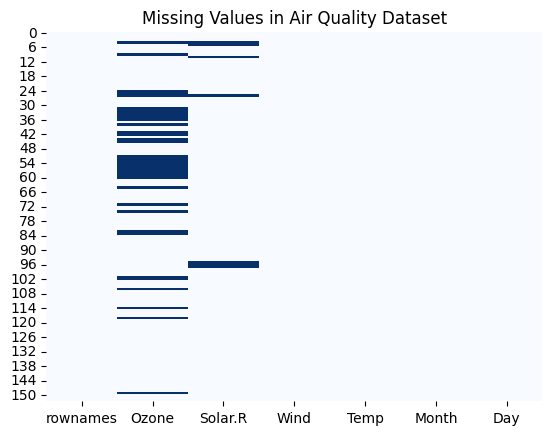

In [28]:
sns.heatmap(df1.isnull(), cbar=False, cmap='Blues')
plt.title("Missing Values in Air Quality Dataset")
plt.show()

In [29]:
df1['Ozone'] = df1['Ozone'].fillna(df1['Ozone'].median())
df1['Solar.R'] = df1['Solar.R'].fillna(df1['Solar.R'].median())


In [30]:
print("Missing values AFTER:")
df1.isnull().sum()

Missing values AFTER:


rownames    0
Ozone       0
Solar.R     0
Wind        0
Temp        0
Month       0
Day         0
dtype: int64

In [ ]:
#encoding

In [76]:
df2=pd.read_csv(r"C:\Users\Lenovo\Downloads\titanic.csv")
df2.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [77]:
df2.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [78]:
df2.select_dtypes(include='object').columns

Index(['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked'], dtype='object')

In [79]:
df2['Age'].fillna(df2['Age'].median(), inplace=True)
df2['Embarked'].fillna(df2['Embarked'].mode()[0], inplace=True)
df2 = df2.drop(columns=['Name', 'Ticket', 'Cabin'])


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_5704\1676032542.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df2['Age'].fillna(df2['Age'].median(), inplace=True)
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_5704\1676032542.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For

In [80]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df2['Sex_encoded'] = le.fit_transform(df2['Sex'])
df2 = pd.get_dummies(df2, columns=['Embarked'], prefix='Embarked')
df2.head()


,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Sex_encoded,Embarked_C,Embarked_Q,Embarked_S
0,1,0,3,male,22.0,1,0,7.2500,1,False,False,True
1,2,1,1,female,38.0,1,0,71.2833,0,True,False,False
2,3,1,3,female,26.0,0,0,7.9250,0,False,False,True
3,4,1,1,female,35.0,1,0,53.1000,0,False,False,True
4,5,0,3,male,35.0,0,0,8.0500,1,False,False,True


In [81]:
df2[['Embarked_C', 'Embarked_Q', 'Embarked_S']] = df2[['Embarked_C', 'Embarked_Q', 'Embarked_S']].astype(int)
df2.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Sex_encoded,Embarked_C,Embarked_Q,Embarked_S
0,1,0,3,male,22.0,1,0,7.2500,1,0,0,1
1,2,1,1,female,38.0,1,0,71.2833,0,1,0,0
2,3,1,3,female,26.0,0,0,7.9250,0,0,0,1
3,4,1,1,female,35.0,1,0,53.1000,0,0,0,1
4,5,0,3,male,35.0,0,0,8.0500,1,0,0,1


In [ ]:
#data distribution

In [83]:
df3=pd.read_csv(r"C:\Users\Lenovo\Downloads\winequality-red.csv", sep=';')
df3.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [84]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [85]:
df3.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

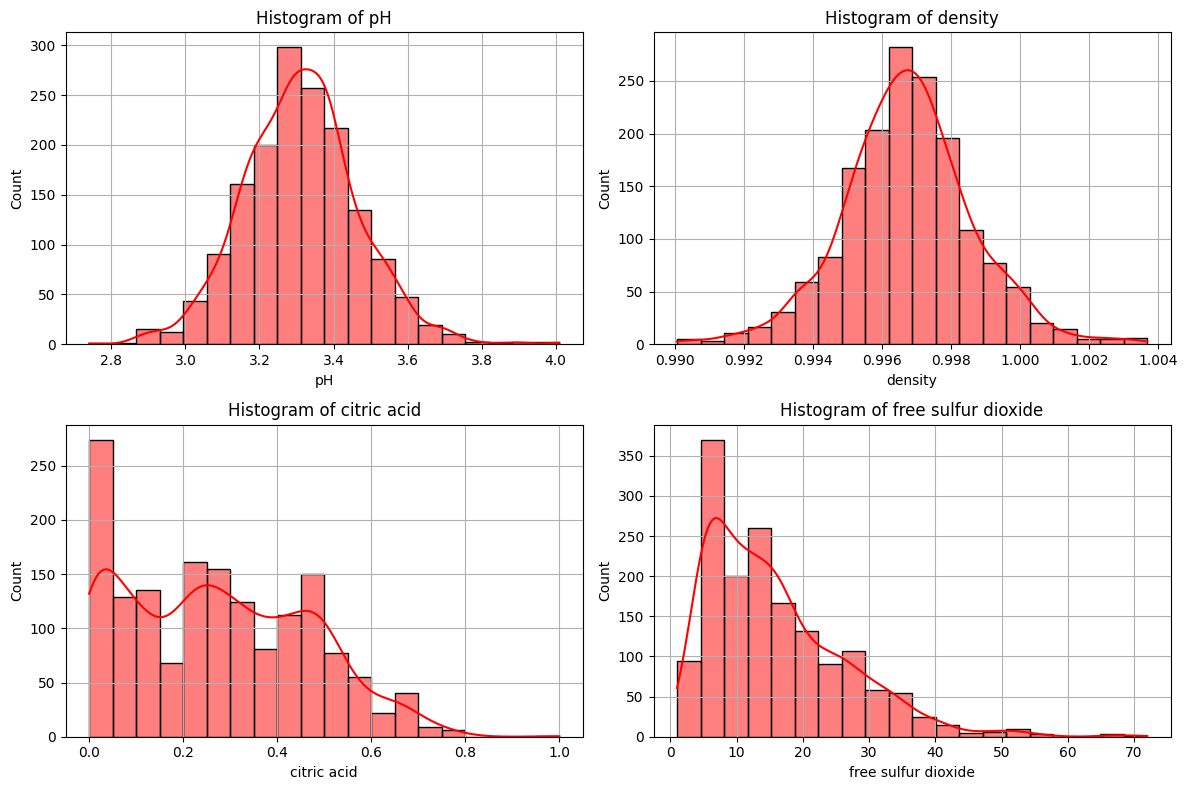

In [101]:
features_hist = ['pH', 'density', 'citric acid', 'free sulfur dioxide']
plt.figure(figsize=(12, 8))

for i, col in enumerate(features_hist, 1):
    plt.subplot(2, 2, i)
    sns.histplot(df3[col], bins=20, kde=True, color="red")
    plt.title(f"Histogram of {col}")
    plt.grid('on')

plt.tight_layout()
plt.show()


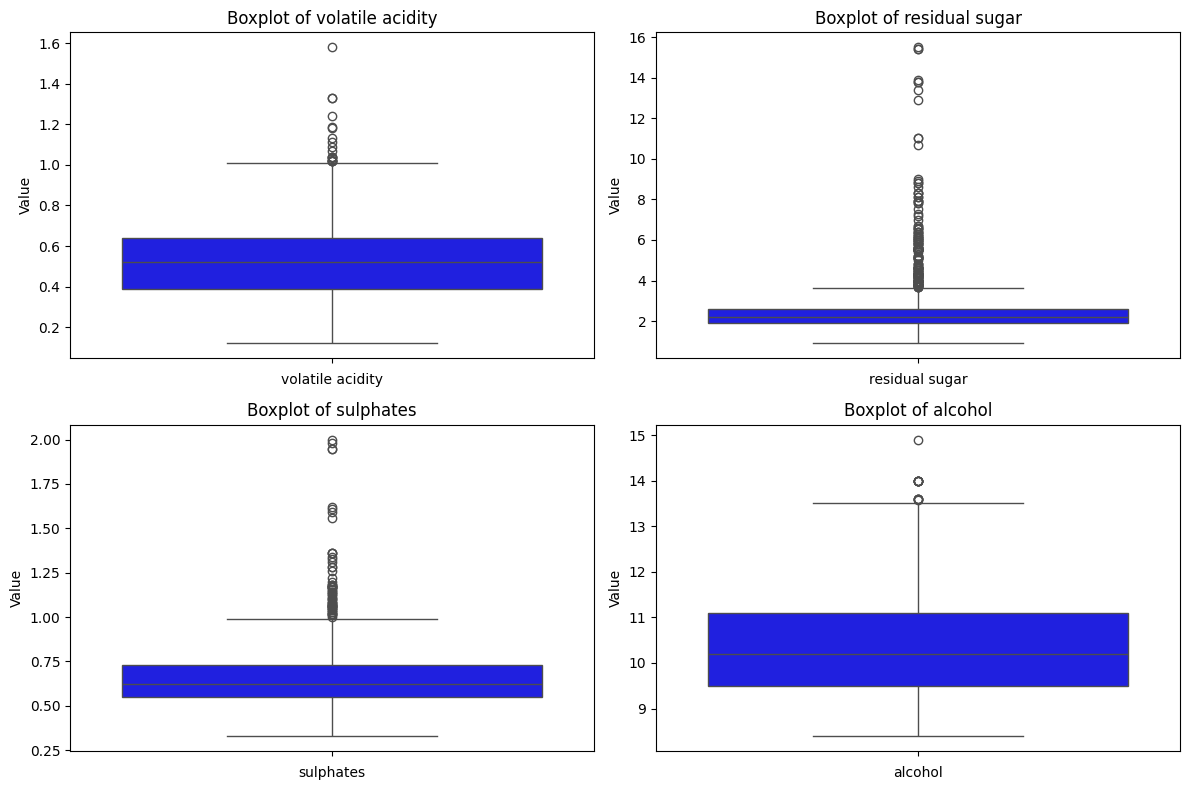

In [99]:
features_box = ['volatile acidity', 'residual sugar', 'sulphates', 'alcohol']
plt.figure(figsize=(12, 8))

for i, col in enumerate(features_box, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(y=df3[col], color="blue")
    plt.xlabel(col) 
    plt.ylabel("Value")
    plt.title(f"Boxplot of {col}")

plt.tight_layout()
plt.show()


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_5704\846677042.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="quality", data=df3, palette="pastel")


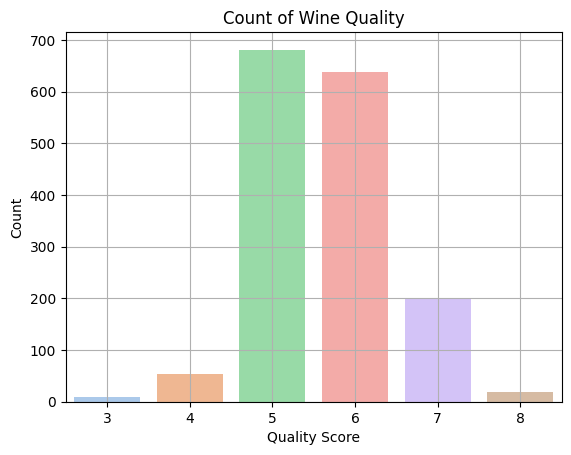

In [3]:
df4=pd.read_csv(r"C:\Users\Lenovo\Downloads\penguins (1).csv")
df4.head()

,rowid,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,1,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,2,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,3,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,4,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,5,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


In [113]:
df4.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   rowid              344 non-null    int64  
 1   species            344 non-null    object 
 2   island             344 non-null    object 
 3   bill_length_mm     342 non-null    float64
 4   bill_depth_mm      342 non-null    float64
 5   flipper_length_mm  342 non-null    float64
 6   body_mass_g        342 non-null    float64
 7   sex                333 non-null    object 
 8   year               344 non-null    int64  
dtypes: float64(4), int64(2), object(3)
memory usage: 24.3+ KB


In [107]:
df4.isnull().sum()

rowid                 0
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
year                  0
dtype: int64

In [114]:
df4 = df4.dropna()


In [115]:
df4.isnull().sum().sum()


np.int64(0)

In [116]:
df4 = df4.drop(['rowid'], axis=1)
df4.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,male,2007


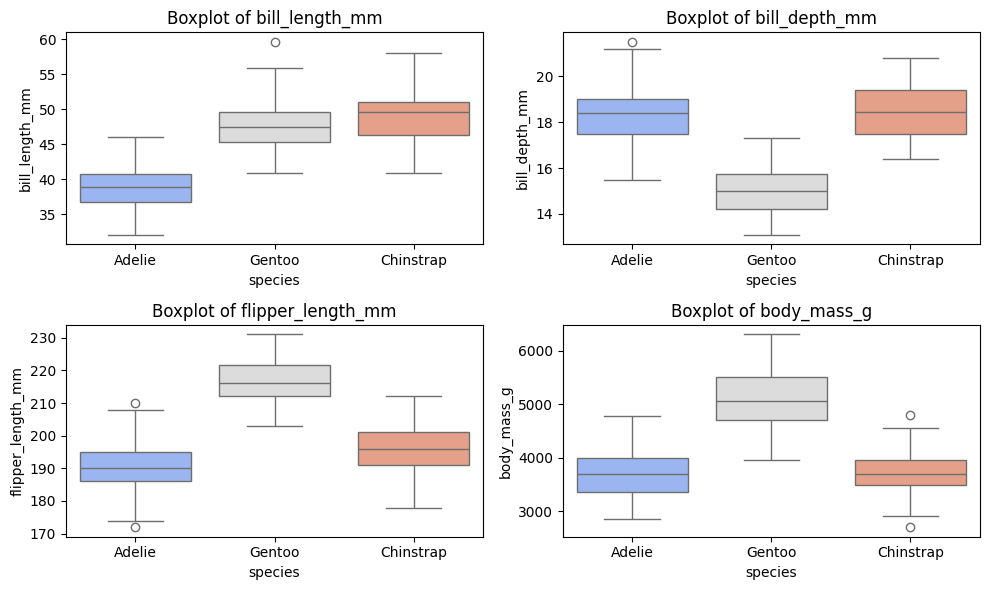

In [118]:
features2=['bill_length_mm','bill_depth_mm','flipper_length_mm','body_mass_g']

plt.figure(figsize=(10, 6))
for i, feature in enumerate(features2, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x="species",  y=df4[feature], data=df4, hue='species', palette='coolwarm')
    plt.title(f"Boxplot of {feature}")
    
plt.tight_layout()
plt.show()

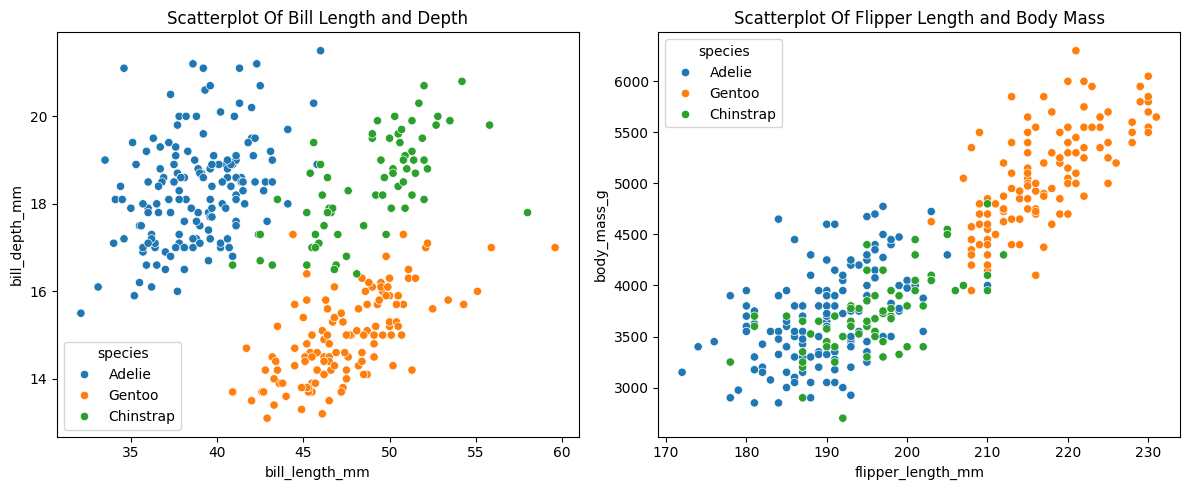

In [6]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.scatterplot(x='bill_length_mm', y='bill_depth_mm', data=df4, hue='species')
plt.title('Scatterplot Of Bill Length and Depth')

plt.subplot(1, 2, 2)
sns.scatterplot(x='flipper_length_mm', y='body_mass_g', data=df4, hue='species')
plt.title('Scatterplot Of Flipper Length and Body Mass')

plt.tight_layout()
plt.show()


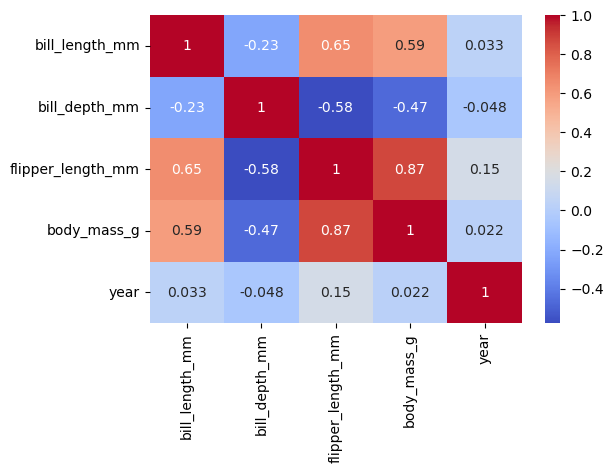

In [71]:
num_df2 = df2.select_dtypes(include='number')
corr_map = num_df2.iloc[:, :5].corr()

plt.figure(figsize=(6,4))
sns.heatmap(corr_map, annot=True, cmap='coolwarm')
plt.show()


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_5704\192849253.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df4, x='species', palette='pastel')


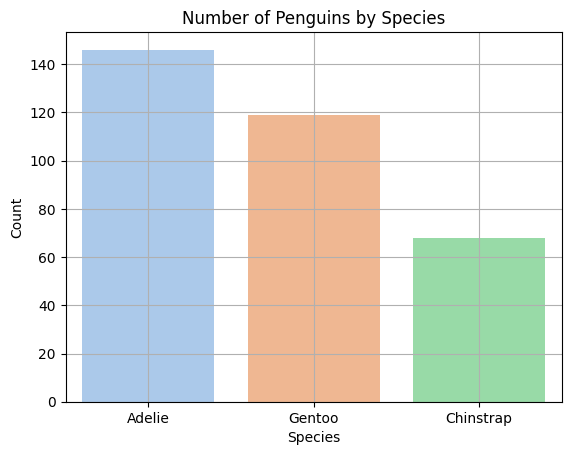

In [121]:
sns.countplot(data=df4, x='species', palette='pastel')
plt.title('Number of Penguins by Species')
plt.xlabel('Species')
plt.ylabel('Count')
plt.grid(')
plt.show()


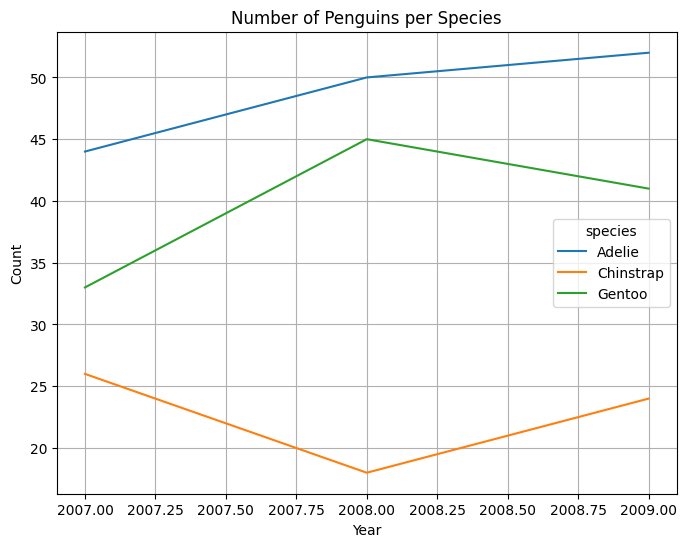

In [130]:
species_year = df4.groupby(['year', 'species']).size().reset_index(name='count')

plt.figure(figsize=(8, 6))
sns.lineplot(data=species_year, x='year', y='count', hue='species')

plt.title('Number of Penguins per Species')
plt.xlabel('Year')
plt.ylabel('Count')
plt.grid()
plt.show()
